In [1]:
from pathlib import Path
import os
import gzip
import struct
import warnings
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Esercizio 1

In [2]:
def sample_corr(A, B):

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    Ac = A - A.mean(axis=0, keepdims=True)  # Centra ogni colonna di A
    Bc = B - B.mean(axis=0, keepdims=True)  # Centra ogni colonna di B

    n = A.shape[0]  # righe di A

    cov = (Ac.T @ Bc) / (n - 1)  # Calcola le covarianze campionarie tra ogni colonna di A e ogni colonna di B

    std_A = Ac.std(axis=0, ddof=1)[:, None]  # DevStan di ogni colonna di A, trasformata in vettore colonna
    std_B = Bc.std(axis=0, ddof=1)[None, :]  # DevStan di ogni colonna di B, trasformata in vettore riga

    with np.errstate(divide="ignore", invalid="ignore"):  # Evita warning se una colonna ha deviazione standard uguale a zero
        corr = cov / (std_A * std_B)  

    return corr

In [3]:
def PCA(X, feature_names=None, standardize=False, low=0.80, high=0.90):
    X = np.asarray(X, dtype=float)
    n, p = X.shape 

    if feature_names is None:  # Se non sono stati forniti i nomi delle variabili li creo automatici
        feature_names = [f"x{j+1}" for j in range(p)]  

    mean = X.mean(axis=0)  # Calcolo la media di ogni colonna
    Xc = X - mean  # Centra i dati sottraendo a ogni variabile la propria media (broadcasting)
    std = Xc.std(axis=0, ddof=1)  # Calcola la deviazione standard campionaria di ogni variabile

    if np.any(std == 0): raise ValueError("Sono presenti variabili costanti: la standardizzazione/PCA non è definita.") 

    Xprep = Xc / std if standardize else Xc   # Standardizza se richiesto

    # S = 1/(n-1) X^T X
    S = (Xprep.T @ Xprep) / (n - 1)

    # S è simmetrica -> eigh restituisce autovalori reali e autovettori ortonormali.
    eigvals, eigvecs = np.linalg.eigh(S)

    # Trovo gli indici che ordinano gli autovalori dal più grande al più piccolo e inverte l'ordine (::-1)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]      # riordino autovalori secondo l'ordine decrescente
    eigvecs = eigvecs[:, order]   # riordino autovettori secondo l'ordine decrescente

    # Calcola la quota di varianza spiegata da ogni componente principale
    explained = eigvals / eigvals.sum()
    cumulative = np.cumsum(explained)

    # Numero minimo di componenti necessario per raggiungere almeno low o high
    k_low = int(np.searchsorted(cumulative, low) + 1)
    k_high = int(np.searchsorted(cumulative, high) + 1)
    k_band = k_low


    # Nuove variabili / scores: Y = Xprep D
    # Proietta le osservazioni sugli autovettori
    # Le colonne di Y sono le componenti principali PC1, PC2, ..., PCp
    Y = Xprep @ eigvecs
    corr = sample_corr(Xprep, Y)


    return {
        "X": X,  # Matrice dati originale
        "Xprep": Xprep,  # Matrice usata effettivamente nella PCA: centrata o standardizzata
        "mean": mean,  # Media di ogni variabile originale
        "std": std,  # Deviazione standard campionaria di ogni variabile
        "cov": S,  # Matrice di covarianza (o correlazione se standardize=True)
        "eigvals": eigvals,  # Autovalori ordinati dal maggiore al minore
        "eigvecs": eigvecs,  # Autovettori associati agli autovalori
        "explained": explained,  # Percentuale/quota di varianza spiegata da ogni PC
        "cumulative": cumulative,  # Varianza spiegata cumulata
        "scores": Y,  # Valori delle nuove variabili/componenti principali
        "corr": corr,  # Correlazioni tra variabili e componenti principali
        "feature_names": list(feature_names),  # Nomi delle variabili
        "standardize": standardize,  # Indica se è stata effettuata la standardizzazione
        "k80": k_low,  # Numero minimo di PC per spiegare almeno l'80%
        "k90": k_high,  # Numero minimo di PC per spiegare almeno il 90%
        "k_band": k_band,  # Numero di PC scelto per la fascia 80%-90%
    }

In [4]:
def report_pca(result, show_scores=True):
    names = result["feature_names"]  # Recupera i nomi delle variabili originali
    p = len(names)  # Numero totale di componenti principali
    pc_names = [f"PC{i+1}" for i in range(p)]  # Crea i nomi PC1, PC2, ..., PCp

    variance_table = pd.DataFrame({
        "autovalore": result["eigvals"],  # Autovalori associati alle componenti principali
        "varianza_spiegata_%": 100 * result["explained"],   # Percentuale di varianza spiegata da ogni componente
        "varianza_cumulata_%": 100 * result["cumulative"],  # Percentuale di varianza spiegata cumulata
        
    }, index=pc_names)


    print(f"k minimo per >=80%: {result['k80']}")
    print(f"k minimo per >=90%: {result['k90']}")

    k = result["k_band"]    # Recupera il numero di componenti scelto per la fascia 80%-90%

    print(f"Scelta per la fascia 80-90%: k = {k}  ->  {100*result['cumulative'][k-1]:.2f}%")

    if result["cumulative"][k-1] > 0.90:
        print("Nota: la prima soglia >=80% supera già il 90%; non esiste un k con cumulata strettamente nella fascia.")

    display(variance_table)   # Mostra la tabella con autovalori, varianza spiegata e cumulata

    loadings = pd.DataFrame(
        result["eigvecs"],
        index=names,
        columns=pc_names
    )
    # Trasforma la matrice degli autovettori in un DataFrame
    # Righe = variabili originali
    # Colonne = componenti principali


    corr = pd.DataFrame(
        result["corr"],
        index=names,
        columns=pc_names
    )
    # Trasforma la matrice delle correlazioni variabili-PC in un DataFrame


    print("Loadings (autovettori):")
    # Titolo della tabella dei loadings


    display(loadings.iloc[:, :max(result["k90"], 3)].round(4))
    # Mostra i loadings delle prime componenti
    # Mostra almeno 3 componenti oppure fino a k90 se k90 è maggiore
    # round(4) arrotonda a 4 cifre decimali


    print("Correlazioni r_{y_i,x_k} tra componenti e variabili:")
    # Titolo della tabella delle correlazioni


    display(corr.iloc[:, :max(result["k90"], 3)].round(4))
    # Mostra le correlazioni tra variabili originali e prime componenti principali
    # Mostra almeno 3 componenti oppure fino a k90


    if show_scores:
        # Se show_scores=True, mostra anche i valori delle nuove variabili

        scores = pd.DataFrame(
            result["scores"][:, :k],
            columns=[f"y{i+1}" for i in range(k)]
        )
        # Prende solo le prime k componenti scelte
        # e crea una tabella con colonne y1, y2, ..., yk

        print("Nuove variabili (scores) per le componenti scelte:")
        # Titolo della tabella degli scores

        display(scores)
        # Mostra i valori delle componenti principali per ogni osservazione


    return variance_table, loadings, corr
    # Restituisce le tre tabelle create

In [5]:
def plot_pca(result, title="PCA"):

    p = len(result["eigvals"]) # Numero totale di componenti principali

    x = np.arange(1, p + 1)   # Crea il vettore [1, 2, ..., p] da usare sull'asse x

    plt.figure(figsize=(8, 4.5))
    plt.bar(x, 100 * result["explained"])  # Grafico a barre della percentuale di varianza spiegata da ogni singola componente
    plt.plot(x, 100 * result["cumulative"], marker="o")  # Disegna la curva della varianza spiegata cumulata
    plt.axhline(80, linestyle="--", linewidth=1)  # Disegna una linea orizzontale tratteggiata all'80%
    plt.axhline(90, linestyle="--", linewidth=1)  # Disegna una linea orizzontale tratteggiata al 90%
    plt.xticks(x)  # Imposta sull'asse x i numeri 1, 2, ..., p
    plt.xlabel("Numero di componenti")   # Etichetta dell'asse x
    plt.ylabel("Varianza (%)")  # Etichetta dell'asse y
    plt.title(title + " - varianza spiegata")  # Titolo del grafico
    plt.grid(alpha=0.25)  # Aggiunge una griglia leggera al grafico
    plt.show()
    # Visualizza il primo grafico


    k_plot = max(result["k90"], min(3, p))  # Decide quante componenti mostrare nel secondo grafico (minimo 3)
    corr = result["corr"][:, :k_plot]  # Seleziona le correlazioni relative alle prime k_plot componenti


    plt.figure(
        figsize=(
            max(6, k_plot * 1.6),
            max(4, len(result["feature_names"]) * 0.45)
        )
    )


    im = plt.imshow(
        corr,
        aspect="auto",      # aspect="auto" adatta automaticamente le celle
        vmin=-1,
        vmax=1,       # vmin=-1 e vmax=1 fissano la scala delle correlazioni
        cmap="coolwarm"      # coolwarm assegna colori diversi a correlazioni negative e positive
    )
    # Visualizza la matrice delle correlazioni come una heatmap

    plt.colorbar(im, label="correlazione")   # Aggiunge una barra laterale che mostra la scala delle correlazioni
    plt.yticks(
        np.arange(len(result["feature_names"])),
        result["feature_names"]
    )    # Mette sull'asse y i nomi delle variabili originali

    plt.xticks(
        np.arange(k_plot),
        [f"PC{i+1}" for i in range(k_plot)]
    )    # Mette sull'asse x i nomi PC1, PC2, ..., PCk

    plt.title(title + " - correlazione variabili / PC")   # Titolo della heatmap
    plt.tight_layout()  # Sistema automaticamente gli spazi per evitare sovrapposizioni
    plt.show()   # Visualizza la heatmap

In [6]:
DETROIT_COLUMNS = ["FTP", "UEMP", "MAN", "LIC", "GR", "CLEAR", "WM", "NMAN", "GOV", "HE", "WE", "HOM", "ACC", "ASR"]


def load_detroit():
    path = r"C:\Users\frmar\OneDrive\Desktop\FRANCESCO\UNIVERSITA\MAGISTRALE\1 ANNO\1A2S\Data Mining\Esercitazione\2 es\Dataset\Detroit.mat"
    data = loadmat(path)
    arr = data["Detroit"]
    print("Detroit caricato da:", path)

    return pd.DataFrame(arr, columns=DETROIT_COLUMNS)


detroit = load_detroit()
display(detroit)
print("Shape:", detroit.shape)

Detroit caricato da: C:\Users\frmar\OneDrive\Desktop\FRANCESCO\UNIVERSITA\MAGISTRALE\1 ANNO\1A2S\Data Mining\Esercitazione\2 es\Dataset\Detroit.mat


,FTP,UEMP,MAN,LIC,GR,CLEAR,WM,NMAN,GOV,HE,WE,HOM,ACC,ASR
0,260.35,11.0,455.5,178.15,215.98,93.4,558724.0,538.1,133.9,2.98,117.18,8.60,39.17,306.18
1,269.80,7.0,480.2,156.41,180.48,88.5,538584.0,547.6,137.6,3.09,134.02,8.90,40.27,315.16
2,272.04,5.2,506.1,198.02,209.57,94.4,519171.0,562.8,143.6,3.23,141.68,8.52,45.31,277.53
3,272.96,4.3,535.8,222.10,231.67,92.0,500457.0,591.0,150.3,3.33,147.98,8.89,49.51,234.07
4,272.51,3.5,576.0,301.92,297.65,91.0,482418.0,626.1,164.3,3.46,159.85,13.07,55.05,230.84
5,261.34,3.2,601.7,391.22,367.62,87.4,465029.0,659.8,179.5,3.60,157.19,14.57,53.90,217.99
6,268.89,4.1,577.3,665.56,616.54,88.3,448267.0,686.2,187.5,3.73,155.29,21.36,50.62,286.11
7,295.99,3.9,596.9,1131.21,1029.75,86.1,432109.0,699.6,195.4,2.91,131.75,28.03,51.47,291.59
8,319.87,3.6,613.5,837.60,786.23,79.0,416533.0,729.9,210.3,4.25,178.74,31.49,49.16,320.39
9,341.43,7.1,569.3,794.90,713.77,73.9,401518.0,757.8,223.8,4.47,178.30,37.39,45.80,323.03


Shape: (13, 14)


k minimo per >=80%: 1
k minimo per >=90%: 1
Scelta per la fascia 80-90%: k = 1  ->  100.00%
Nota: la prima soglia >=80% supera già il 90%; non esiste un k con cumulata strettamente nella fascia.


,autovalore,varianza_spiegata_%,varianza_cumulata_%
PC1,4.169191e+09,9.999829e+01,99.998286
PC2,5.799924e+04,1.391115e-03,99.999677
PC3,9.616988e+03,2.306640e-04,99.999908
PC4,3.185918e+03,7.641444e-05,99.999984
PC5,4.768310e+02,1.143682e-05,99.999995
PC6,1.048551e+02,2.514957e-06,99.999998
PC7,5.929902e+01,1.422291e-06,99.999999
PC8,1.595323e+01,3.826392e-07,100.000000
PC9,6.300480e+00,1.511174e-07,100.000000
PC10,2.583357e+00,6.196198e-08,100.000000


Loadings (autovettori):


,PC1,PC2,PC3
FTP,0.0006,-0.0336,0.1051
UEMP,-0.0000,-0.0010,0.0112
MAN,0.0006,0.0238,-0.1779
LIC,0.0038,0.7818,-0.5522
GR,0.0041,0.6153,0.7477
CLEAR,-0.0002,0.0111,-0.0243
WM,-1.0000,0.0054,0.0012
NMAN,0.0015,0.0029,0.0009
GOV,0.0006,0.0078,0.0054
HE,0.0000,-0.0016,0.0017


Correlazioni r_{y_i,x_k} tra componenti e variabili:


,PC1,PC2,PC3
FTP,0.8839,-0.1730,0.2201
UEMP,-0.0731,-0.1059,0.4652
MAN,0.7528,0.1152,-0.3502
LIC,0.7837,0.5950,-0.1711
GR,0.8458,0.4764,0.2358
CLEAR,-0.8906,0.2117,-0.1882
WM,-1.0000,0.0000,0.0000
NMAN,0.9943,0.0073,0.0009
GOV,0.9886,0.0507,0.0144
HE,0.8667,-0.4006,0.1709


Nuove variabili (scores) per le componenti scelte:


,y1
0,-106217.654098
1,-86078.186290
2,-66665.235107
3,-47951.350045
4,-29912.007136
5,-12522.632255
6,4241.222438
7,20402.452978
8,35976.184259
9,50990.498980


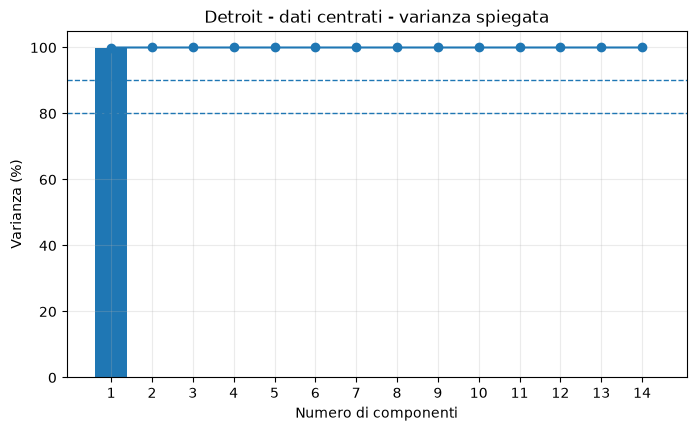

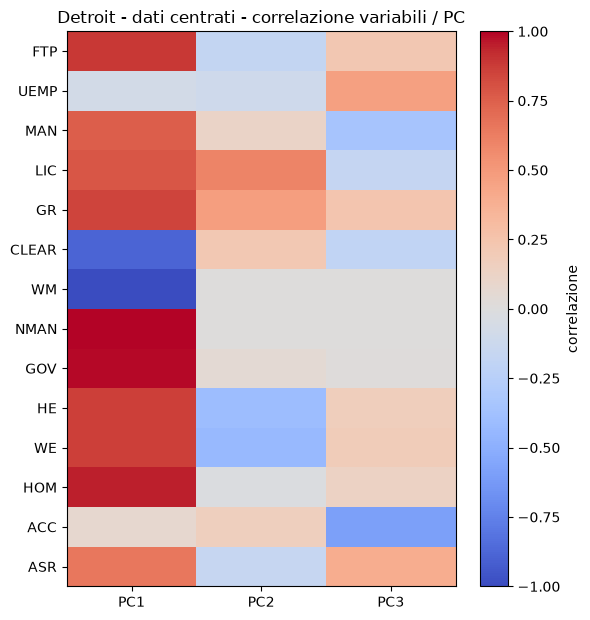

In [7]:
pca_detroit_raw = PCA(detroit.values, detroit.columns, standardize=False)
report_pca(pca_detroit_raw, "Detroit - PCA sui dati centrati")
plot_pca(pca_detroit_raw, "Detroit - dati centrati")

In [8]:
# Sintesi automatica delle variabili più legate alle prime componenti.
def top_relations(result, n_top=4):
    names = np.array(result["feature_names"])
    for j in range(max(result["k90"], 3)):
        order = np.argsort(np.abs(result["corr"][:, j]))[::-1][:n_top]
        pairs = ", ".join(f"{names[i]} ({result['corr'][i,j]:+.3f})" for i in order)
        print(f"PC{j+1}: {pairs}")

print("Variabili con maggiore |correlazione| con le PC (Detroit non standardizzato):")
top_relations(pca_detroit_raw)

Variabili con maggiore |correlazione| con le PC (Detroit non standardizzato):
PC1: WM (-1.000), NMAN (+0.994), GOV (+0.989), HOM (+0.953)
PC2: LIC (+0.595), GR (+0.476), WE (-0.436), HE (-0.401)
PC3: ACC (-0.593), UEMP (+0.465), ASR (+0.391), MAN (-0.350)


### PCA dopo standardizzazione

k minimo per >=80%: 2
k minimo per >=90%: 2
Scelta per la fascia 80-90%: k = 2  ->  90.64%
Nota: la prima soglia >=80% supera già il 90%; non esiste un k con cumulata strettamente nella fascia.


,autovalore,varianza_spiegata_%,varianza_cumulata_%
PC1,9.601756e+00,6.858397e+01,68.583969
PC2,3.087688e+00,2.205492e+01,90.638887
PC3,8.507166e-01,6.076547e+00,96.715434
PC4,2.180283e-01,1.557345e+00,98.272780
PC5,9.225492e-02,6.589637e-01,98.931743
PC6,5.758042e-02,4.112887e-01,99.343032
PC7,4.247761e-02,3.034115e-01,99.646444
PC8,2.179516e-02,1.556797e-01,99.802123
PC9,1.925855e-02,1.375611e-01,99.939684
PC10,6.385224e-03,4.560874e-02,99.985293


Loadings (autovettori):


,PC1,PC2,PC3
FTP,-0.3076,-0.1349,-0.0730
UEMP,-0.0360,-0.5209,0.2739
MAN,-0.2014,0.4275,-0.1444
LIC,-0.2360,0.2341,0.5644
GR,-0.2674,0.1333,0.4857
CLEAR,0.3087,0.1331,0.1091
WM,0.3150,-0.1147,0.0222
NMAN,-0.3158,0.1024,-0.0049
GOV,-0.3141,0.0897,0.0667
HE,-0.2968,-0.1181,-0.3375


Correlazioni r_{y_i,x_k} tra componenti e variabili:


,PC1,PC2,PC3
FTP,-0.9533,-0.2371,-0.0673
UEMP,-0.1117,-0.9152,0.2526
MAN,-0.6240,0.7512,-0.1332
LIC,-0.7313,0.4114,0.5206
GR,-0.8287,0.2342,0.4480
CLEAR,0.9566,0.2338,0.1006
WM,0.9760,-0.2016,0.0204
NMAN,-0.9784,0.1799,-0.0045
GOV,-0.9734,0.1576,0.0615
HE,-0.9196,-0.2075,-0.3113


Nuove variabili (scores) per le componenti scelte:


,y1,y2
0,3.812665,-3.160417
1,3.299930,-2.087225
2,3.184188,-0.649277
3,2.839482,0.477462
4,2.080740,1.729843
5,1.496027,2.124651
6,0.471866,1.439039
7,-0.458544,2.329427
8,-1.647434,1.543292
9,-2.191140,-0.107133


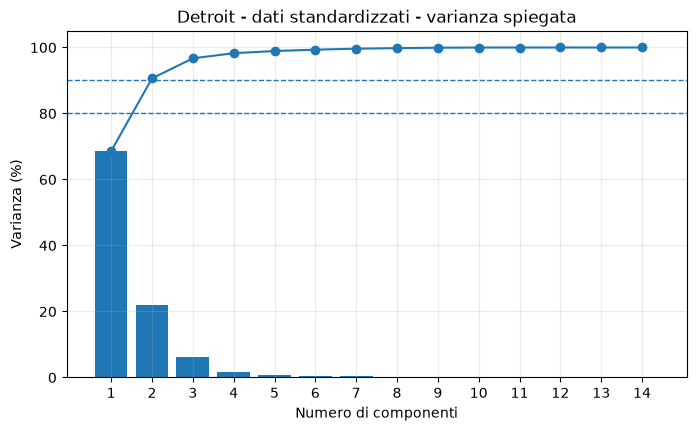

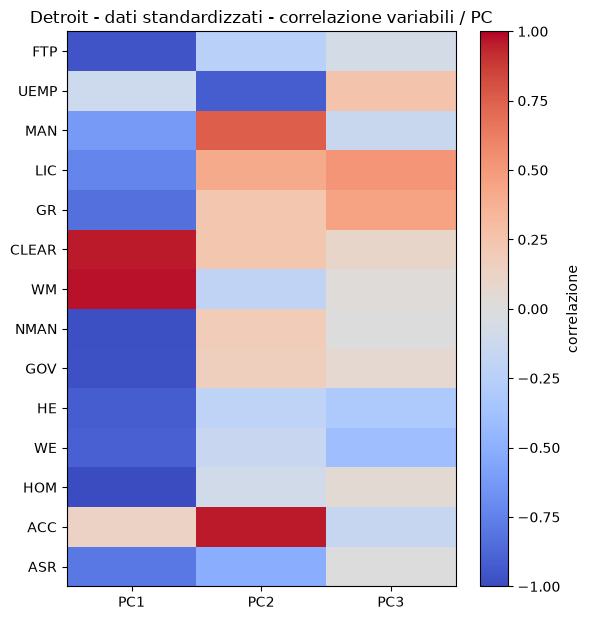

Variabili con maggiore |correlazione| con le PC (Detroit standardizzato):
PC1: HOM (-0.993), NMAN (-0.978), WM (+0.976), GOV (-0.973)
PC2: ACC (+0.957), UEMP (-0.915), MAN (+0.751), ASR (-0.516)
PC3: LIC (+0.521), GR (+0.448), WE (-0.391), HE (-0.311)


In [9]:
pca_detroit_std = PCA(detroit.values, detroit.columns, standardize=True)
report_pca(pca_detroit_std, "Detroit - PCA dopo standardizzazione")
plot_pca(pca_detroit_std, "Detroit - dati standardizzati")

print("Variabili con maggiore |correlazione| con le PC (Detroit standardizzato):")
top_relations(pca_detroit_std)

In [10]:
# Confronto diretto prima/dopo standardizzazione.
comparison_detroit = pd.DataFrame({
    "analisi": ["centrata", "standardizzata"],
    "k >= 80%": [pca_detroit_raw["k80"], pca_detroit_std["k80"]],
    "k >= 90%": [pca_detroit_raw["k90"], pca_detroit_std["k90"]],
    "varianza cumulata con k80 (%)": [
        100*pca_detroit_raw["cumulative"][pca_detroit_raw["k80"]-1],
        100*pca_detroit_std["cumulative"][pca_detroit_std["k80"]-1],
    ],
})
display(comparison_detroit)

print("Conclusione Detroit:")
print(f"- senza standardizzazione, {pca_detroit_raw['k80']} PC spiega già "
      f"{100*pca_detroit_raw['cumulative'][pca_detroit_raw['k80']-1]:.2f}% della varianza;")
print(f"- con standardizzazione, {pca_detroit_std['k80']} PC spiegano "
      f"{100*pca_detroit_std['cumulative'][pca_detroit_std['k80']-1]:.2f}% della varianza;")
print(f"- per una soglia stretta >=90% dopo standardizzazione servono {pca_detroit_std['k90']} PC.")

,analisi,k >= 80%,k >= 90%,varianza cumulata con k80 (%)
0,centrata,1,1,99.998286
1,standardizzata,2,2,90.638887


Conclusione Detroit:
- senza standardizzazione, 1 PC spiega già 100.00% della varianza;
- con standardizzazione, 2 PC spiegano 90.64% della varianza;
- per una soglia stretta >=90% dopo standardizzazione servono 2 PC.


# Esercizio 2

In [11]:
def matching_pursuit(D, y, k, tol=1e-10, normalize_columns=False):
    
    D = np.asarray(D, dtype=float) # Dizionario D -> matrice 
    y = np.asarray(y, dtype=float).ravel()   #ravel (n,1) -> (n,)
    n, m = D.shape  # n righe, m colonne

    if y.size != n:  # Verifico che y abbia la stessa dimensione delle colonne di D.
        raise ValueError("Dimensioni incompatibili tra D e y")


    if k > m: k = m  # Impossibile selezionare più di m colonne.

    if normalize_columns:
        norms = np.linalg.norm(D, axis=0)
        norms[norms == 0] = 1.0   #se colonna con solo zeri
        Dw = D / norms

    else:
        norms = np.ones(m)   #se non normalizzo
        Dw = D

    xw = np.zeros(m)  #all'inizio tutti i coefficienti sono zer
    r = y.copy()  #r_0 = 
    I = []
    history = [np.linalg.norm(r)] # salvo le norme dei residui

    for _ in range(k):

        corr = Dw.T @ r

        if I: corr[np.array(I, dtype=int)] = 0.0  # dalla seconda iterazione in poi, escludo gli atomi già scelti

        j = int(np.argmax(np.abs(corr)))  #argmax da l'indice dove succede

        denom = float(Dw[:, j] @ Dw[:, j])

        if denom <= np.finfo(float).eps: break

        alpha = float(Dw[:, j] @ r) / denom

        xw[j] = alpha

        I.append(j)  # inserisco j nel supporto.
 
        r = y - Dw @ xw

        history.append(np.linalg.norm(r))

        if history[-1] < tol: break

        #ENDFOR

    x = xw / norms

    return x, I, np.array(history), y - D @ x

In [12]:
def orthogonal_matching_pursuit(D, y, k, tol=1e-10, normalize_columns=False):
    
    D = np.asarray(D, dtype=float) # Dizionario D -> matrice
    y = np.asarray(y, dtype=float).ravel()   # ravel (n,1) -> (n,)
    n, m = D.shape  # n righe, m colonne

    if y.size != n:  # Verifico che y abbia la stessa dimensione delle colonne di D.
        raise ValueError("Dimensioni incompatibili tra D e y")

    if k > m: k = m  # Impossibile selezionare più di m colonne.

    if normalize_columns:
        norms = np.linalg.norm(D, axis=0)
        norms[norms == 0] = 1.0   # se colonna con solo zeri
        Dw = D / norms

    else:
        norms = np.ones(m)   # se non normalizzo
        Dw = D

    xw = np.zeros(m)  # all'inizio tutti i coefficienti sono zero
    r = y.copy()      # r_0 = y
    I = []
    history = [np.linalg.norm(r)]  # salvo le norme dei residui

    for _ in range(k):

        corr = Dw.T @ r

        if I: corr[np.array(I, dtype=int)] = 0.0  # dalla seconda iterazione in poi, escludo gli atomi già scelti

        j = int(np.argmax(np.abs(corr)))  # argmax dà l'indice dove la correlazione è massima

        I.append(j)  # inserisco j nel supporto

        DI = Dw[:, I]  # creo la matrice con solo le colonne selezionate

        # OMP: ricalcolo tutti i coefficienti delle colonne attive
        # risolvendo il problema ai minimi quadrati:
        # min || y - DI*a ||_2
        coeffs, *_ = np.linalg.lstsq(DI, y, rcond=None)

        xw[:] = 0.0  # azzero tutti i coefficienti

        xw[np.array(I)] = coeffs  # inserisco i coefficienti ricalcolati nelle posizioni del supporto

        r = y - Dw @ xw  # aggiorno il residuo

        history.append(np.linalg.norm(r))  # salvo la norma del residuo

        if history[-1] < tol: break

        # ENDFOR

    x = xw / norms

    return x, I, np.array(history), y - D @ x

In [13]:
import gzip
import struct
import urllib.request
import time
import numpy as np
from pathlib import Path


# Cartella Fashion-MNIST
FASHION_DIR = Path("fashion_all")
FASHION_DIR.mkdir(exist_ok=True)


# File necessari
URLS = {
    "train-images-idx3-ubyte.gz":
        "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/train-images-idx3-ubyte.gz",

    "train-labels-idx1-ubyte.gz":
        "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/train-labels-idx1-ubyte.gz",

    "t10k-images-idx3-ubyte.gz":
        "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/t10k-images-idx3-ubyte.gz",

    "t10k-labels-idx1-ubyte.gz":
        "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/t10k-labels-idx1-ubyte.gz"
}


def download_file(url, path, tentativi=5):
    """Scarica un file provando più volte in caso di errore."""

    for i in range(tentativi):

        try:

            print(f"Download {path.name}...")

            urllib.request.urlretrieve(
                url,
                path
            )

            print("Completato.")

            return

        except Exception as e:

            print("Errore:", e)

            # elimino eventuale file incompleto
            if path.exists():
                path.unlink()

            if i == tentativi - 1:
                raise

            time.sleep(2)


def read_idx_gz(path):
    """Legge i file IDX compressi di Fashion-MNIST."""

    with gzip.open(path, "rb") as f:

        magic = struct.unpack(
            ">I",
            f.read(4)
        )[0]

        # Immagini
        if magic == 2051:

            n, rows, cols = struct.unpack(
                ">III",
                f.read(12)
            )

            data = np.frombuffer(
                f.read(),
                dtype=np.uint8
            )

            return data.reshape(
                n,
                rows * cols
            )

        # Etichette
        elif magic == 2049:

            n = struct.unpack(
                ">I",
                f.read(4)
            )[0]

            return np.frombuffer(
                f.read(),
                dtype=np.uint8,
                count=n
            )

        else:

            raise ValueError(
                f"Formato IDX non riconosciuto: {magic}"
            )


def load_fashion_mnist():
    """Carica Fashion-MNIST dai file IDX."""

    # Scarico solo i file mancanti
    for nome, url in URLS.items():

        path = FASHION_DIR / nome

        if not path.exists():

            download_file(
                url,
                path
            )


    # Percorsi dei file
    train_images = FASHION_DIR / "train-images-idx3-ubyte.gz"
    train_labels = FASHION_DIR / "train-labels-idx1-ubyte.gz"

    test_images = FASHION_DIR / "t10k-images-idx3-ubyte.gz"
    test_labels = FASHION_DIR / "t10k-labels-idx1-ubyte.gz"


    # Training set
    X_train = read_idx_gz(train_images)
    y_train = read_idx_gz(train_labels)

    # Test set
    X_test = read_idx_gz(test_images)
    y_test = read_idx_gz(test_labels)


    # Unisco train e test
    X = np.vstack([
        X_train,
        X_test
    ])

    y = np.concatenate([
        y_train,
        y_test
    ])


    # Conversione e normalizzazione
    X = X.astype(np.float32) / 255.0
    y = y.astype(int)

    return X, y

In [ ]:
random_idx = np.random.randint(0, X_fashion.shape[0])
image = X_fashion[random_idx].reshape(28, 28)

print("Indice:", random_idx)
print("Dimensioni immagine:", image.shape)
print("Dimensioni dataset:", X_fashion.shape)
print("Classe:", y_fashion[random_idx])

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Immagine casuale - classe {y_fashion[random_idx]}")
plt.axis("off")
plt.show()

In [14]:
X_fashion, y_fashion = load_fashion_mnist()

print("X_fashion:", X_fashion.shape)
print("y_fashion:", y_fashion.shape)

print(
    "Range pixel:",
    X_fashion.min(),
    X_fashion.max()
)

X_fashion: (70000, 784)
y_fashion: (70000,)
Range pixel: 0.0 1.0


In [15]:
# Parametri scelti dall'utente
nD = 500  # Numero di immagini da inserire nel dizionario

k_sparse = 12  # Numero massimo di coefficienti non nulli nella rappresentazione sparsa

TARGET_INDEX = 12345  # Indice dell'immagine che voglio ricostruire


if X_fashion is not None:  # Esegue il codice solo se Fashion-MNIST è stato caricato

    N = X_fashion.shape[0]  # Numero totale di immagini presenti nel dataset

    target_idx = TARGET_INDEX % N
    # Se TARGET_INDEX fosse maggiore di N, % permette di ottenere comunque un indice valido


    pool = np.delete(np.arange(N), target_idx)
    # Crea l'insieme degli indici utilizzabili per il dizionario
    # escludendo l'immagine target che vogliamo ricostruire


    nD_eff = min(nD, len(pool))
    # Numero effettivo di immagini da usare nel dizionario
    # Se nD è maggiore delle immagini disponibili, usa tutte quelle disponibili


    dict_idx = rng.choice(
        pool,
        size=nD_eff,
        replace=False
    )
    # Seleziona casualmente nD_eff immagini dal dataset
    # replace=False evita di scegliere più volte la stessa immagine


    y_img = X_fashion[target_idx]
    # Estrae l'immagine target da ricostruire
    # L'immagine è rappresentata come un vettore di 784 elementi


    D_img = X_fashion[dict_idx].T
    # Costruisce il dizionario D usando le immagini selezionate
    # X_fashion[dict_idx] ha dimensione nD_eff x 784
    # Con la trasposta otteniamo D di dimensione 784 x nD_eff
    # Ogni colonna di D rappresenta quindi un'immagine / atomo del dizionario


    print(
        "Dimensione del dizionario D:",
        D_img.shape
    )
    # Stampa la dimensione del dizionario costruito


    print(
        "Indice immagine target:",
        target_idx,
        "classe:",
        y_fashion[target_idx]
    )
    # Stampa l'indice dell'immagine target e la sua classe Fashion-MNIST


    print(
        "Target presente nel dizionario?",
        target_idx in dict_idx
    )
    # Controlla che l'immagine target non sia stata inserita anche nel dizionario


else:

    D_img = None  # Il dizionario non può essere costruito

    y_img = None  # L'immagine target non è disponibile

    dict_idx = None  # Non esistono indici delle immagini del dizionario

NameError: name 'rng' is not defined

,metodo,||x||_0,errore_relativo,||residuo||_2
0,MP,12,0.3593,6.1142
1,OMP,12,0.2830,4.8150


Classi degli atomi selezionati da MP: [8, 9, 9, 0, 8, 8, 8, 7, 8, 2, 8, 5]
Classi degli atomi selezionati da OMP: [8, 9, 0, 8, 8, 5, 2, 5, 8, 6, 8, 9]


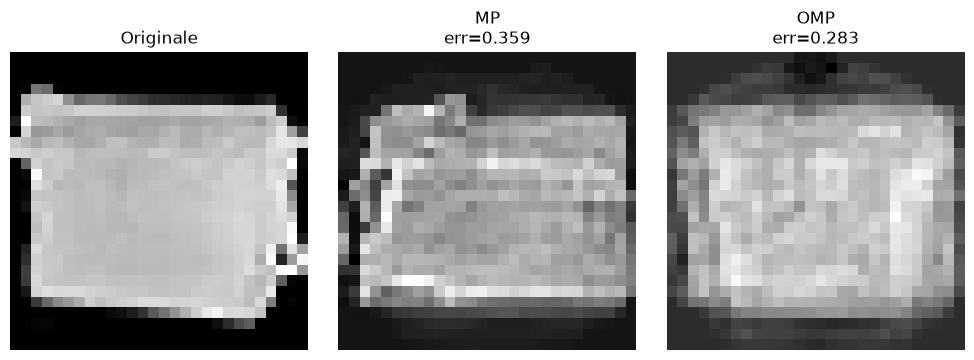

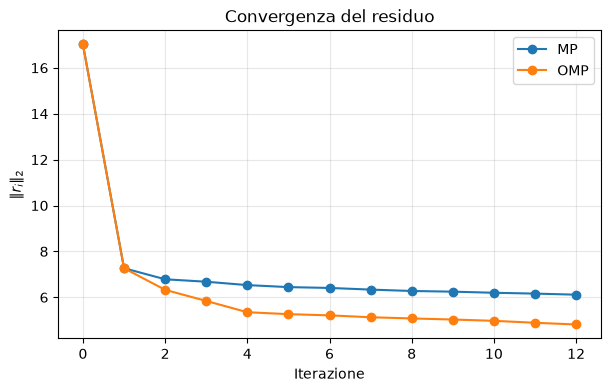


Conclusione:
MP mantiene fissi i coefficienti calcolati nelle iterazioni precedenti.
OMP, invece, dopo aver aggiunto un nuovo atomo, ricalcola tutti i coefficienti attivi tramite minimi quadrati.
Per questo motivo OMP tende generalmente a ottenere un residuo minore rispetto a MP.


In [ ]:
if D_img is not None:  # Esegue il confronto solo se il dizionario delle immagini è disponibile

    x_mp, supp_mp, hist_mp, res_mp = matching_pursuit(
        D_img,
        y_img,
        k=k_sparse,
        normalize_columns=True
    )
    # Calcola la rappresentazione sparsa dell'immagine y_img con Matching Pursuit
    # x_mp = coefficienti, supp_mp = atomi scelti, hist_mp = storia del residuo, res_mp = residuo finale


    x_omp, supp_omp, hist_omp, res_omp = orthogonal_matching_pursuit(
        D_img,
        y_img,
        k=k_sparse,
        normalize_columns=True
    )
    # Calcola la rappresentazione sparsa dell'immagine y_img con Orthogonal Matching Pursuit


    y_mp = D_img @ x_mp
    # Ricostruisce l'immagine usando i coefficienti ottenuti con MP: y_MP = D x_MP


    y_omp = D_img @ x_omp
    # Ricostruisce l'immagine usando i coefficienti ottenuti con OMP: y_OMP = D x_OMP


    rel_mp = np.linalg.norm(y_img - y_mp) / np.linalg.norm(y_img)
    # Calcola l'errore relativo della ricostruzione ottenuta con MP


    rel_omp = np.linalg.norm(y_img - y_omp) / np.linalg.norm(y_img)
    # Calcola l'errore relativo della ricostruzione ottenuta con OMP


    comparison = pd.DataFrame({

        "metodo": [
            "MP",
            "OMP"
        ],  # Nomi dei due metodi confrontati

        "||x||_0": [
            np.count_nonzero(np.abs(x_mp) > 1e-12),
            np.count_nonzero(np.abs(x_omp) > 1e-12)
        ],  # Numero di coefficienti non nulli delle due rappresentazioni sparse

        "errore_relativo": [
            rel_mp,
            rel_omp
        ],  # Errore relativo delle due ricostruzioni

        "||residuo||_2": [
            np.linalg.norm(res_mp),
            np.linalg.norm(res_omp)
        ]  # Norma euclidea del residuo finale
    })

    display(comparison)  # Mostra la tabella di confronto tra MP e OMP


    classi_mp = y_fashion[
        dict_idx[np.array(supp_mp)]
    ]
    # Recupera le classi Fashion-MNIST degli atomi selezionati da MP


    classi_omp = y_fashion[
        dict_idx[np.array(supp_omp)]
    ]
    # Recupera le classi Fashion-MNIST degli atomi selezionati da OMP


    print(
        "Classi degli atomi selezionati da MP:",
        classi_mp.tolist()
    )
    # Stampa le classi degli atomi scelti da MP


    print(
        "Classi degli atomi selezionati da OMP:",
        classi_omp.tolist()
    )
    # Stampa le classi degli atomi scelti da OMP


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(10, 3.5)
    )
    # Crea una figura con tre grafici affiancati


    axes[0].imshow(
        y_img.reshape(28, 28),
        cmap="gray"
    )
    # Visualizza l'immagine originale trasformando il vettore in una matrice 28x28

    axes[0].set_title("Originale")  # Titolo dell'immagine originale


    axes[1].imshow(
        y_mp.reshape(28, 28),
        cmap="gray"
    )
    # Visualizza l'immagine ricostruita con Matching Pursuit

    axes[1].set_title(
        f"MP\nerr={rel_mp:.3f}"
    )
    # Mostra nel titolo anche l'errore relativo di MP


    axes[2].imshow(
        y_omp.reshape(28, 28),
        cmap="gray"
    )
    # Visualizza l'immagine ricostruita con Orthogonal Matching Pursuit

    axes[2].set_title(
        f"OMP\nerr={rel_omp:.3f}"
    )
    # Mostra nel titolo anche l'errore relativo di OMP


    for ax in axes:
        ax.axis("off")
    # Nasconde gli assi dei tre grafici perché si stanno visualizzando immagini


    plt.tight_layout()  # Sistema automaticamente gli spazi tra i grafici

    plt.show()  # Visualizza il confronto tra le tre immagini


    plt.figure(figsize=(7, 4))  # Crea una nuova figura per confrontare i residui


    plt.plot(
        np.arange(len(hist_mp)),
        hist_mp,
        marker="o",
        label="MP"
    )
    # Disegna l'andamento della norma del residuo di MP a ogni iterazione


    plt.plot(
        np.arange(len(hist_omp)),
        hist_omp,
        marker="o",
        label="OMP"
    )
    # Disegna l'andamento della norma del residuo di OMP a ogni iterazione


    plt.xlabel("Iterazione")  # Etichetta dell'asse x

    plt.ylabel(r"$\|r_i\|_2$")  # Etichetta dell'asse y: norma del residuo

    plt.title("Convergenza del residuo")  # Titolo del grafico

    plt.grid(alpha=0.3)  # Aggiunge una griglia leggera

    plt.legend()  # Mostra la legenda con MP e OMP

    plt.show()  # Visualizza il grafico della convergenza


    print("\nConclusione:")  # Introduce il confronto finale tra i due metodi


    print(
        "MP mantiene fissi i coefficienti calcolati "
        "nelle iterazioni precedenti."
    )
    # In MP i coefficienti già calcolati non vengono aggiornati


    print(
        "OMP, invece, dopo aver aggiunto un nuovo atomo, "
        "ricalcola tutti i coefficienti attivi tramite minimi quadrati."
    )
    # In OMP i coefficienti degli atomi selezionati vengono ricalcolati a ogni iterazione


    print(
        "Per questo motivo OMP tende generalmente a ottenere "
        "un residuo minore rispetto a MP."
    )
    # OMP tende quindi a fornire una ricostruzione migliore a parità di numero di atomi


else:

    print(
        "Confronto Fashion-MNIST non eseguito "
        "perché il dataset non è disponibile."
    )
    # Se D_img non è disponibile, il confronto tra MP e OMP non viene eseguito